# Setup

In [1]:
import gc
import os
import sys
import logging
import warnings
from pathlib import Path
import matplotlib as mpl
import pandas as pd
import session_info

SRCDIR = Path('../../..')
HOMEDIR = SRCDIR / '..'
PLOTDIR = HOMEDIR / "plots" / "kennedi_xenium"
DATADIR = HOMEDIR / "data" / "processed" / "spatial" / "Xenium" / "kennedi_flu"
if not str(SRCDIR) in sys.path:
    sys.path.insert(0, str(SRCDIR))

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

import anndata as ad
# import spatialdata as sd
# import spatialdata_plot as sdp

%matplotlib inline
# R_preload()
mpl.rcdefaults()
gc.collect()

session_info.show()

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Click 9.1. Use feature detection or 'importlib.metadata.versio

In [ ]:
CLUSTER_KEY = "global_leiden"
DE_KEY = "global_DEG"
resolutions = np.arange(1, 16) / 10
DOWNSAMPLE = False

# adata.obs['Sample'] = adata.obs['Sample'].str.split("_cells_stats", expand=True)[0]
# adata.obs["Sample"] = adata.obs["Sample"].str.replace("Rest_Tgfbr2F", "Tgfbr2F_Rest")
# adata.obs["Sample"] = adata.obs["Sample"].str.replace("Rest_Ctrl", "Ctrl_Rest").astype("category")
# adata.obs['Genotype'] = adata.obs['Sample'].str.split("_", expand=True)[0].astype("category")
# adata.obs['Timepoint'] = adata.obs['Sample'].str.split("_", expand=True)[1].astype("category")

# Process adata

In [ ]:
if DOWNSAMPLE is True:
    adata = sc.read_h5ad(DATADIR / "downsampled_50K.h5ad")
else:
    adata = sc.read_h5ad(DATADIR / "integrated.h5ad")

adata

In [ ]:
# reset to 0
adata.obsm['SPATIAL'] = adata.obsm['spatial'].copy()
for sample in adata.obs["Sample"].cat.categories:
    sample_idx = adata.obs["Sample"] == sample
    coords = adata.obsm['spatial']

    adata.obsm['SPATIAL'][sample_idx,0] = coords[sample_idx,0] - coords[sample_idx,0].min()
    adata.obsm['SPATIAL'][sample_idx,1] = coords[sample_idx,1] - coords[sample_idx,1].min()

# f,ax = plt.subplots(1,1, layout="constrained")
# sc.pl.embedding(adata, basis='SPATIAL', color="Sample", ax=ax, show=False)

# offset by condition (row)

x_shift_1 = {
    'Ctrl_1' : 0, 'Ctrl_2' : 1,
    'Tgfbr2F_1' : 2, 'Tgfbr2F_2' : 3,
}

x_shift_2 = {
    'Ctrl_1' : 0, 'Ctrl_2' : 1, 'Ctrl_3' : 2,
    'Tgfbr2F_1' : 3, 'Tgfbr2F_2' : 4, 'Tgfbr2F_3' : 5
}

y_shift = {
    'Rest' : 0, 'D3' : 1, 'D7' : 2, 'D14' : 3,
}

x_off, y_off = adata.obsm["SPATIAL"].max(axis=0) * 1.3

for sample in adata.obs["Sample"].cat.categories:
    sample_idx = adata.obs["Sample"] == sample
    x_group = sample.split("_")[0] + "_" + sample.split("_")[2]
    y_group = sample.split("_")[1]

    OFFSET = [
        x_off*x_shift_2[x_group] if y_group == "Rest" else x_off*x_shift_1[x_group],
        y_off*y_shift[y_group]
    ]
    # print(sample, np.round(OFFSET, -3))

    adata.obsm['SPATIAL'][sample_idx,0] = adata.obsm['SPATIAL'][sample_idx,0] + OFFSET[0]
    adata.obsm['SPATIAL'][sample_idx,1] = adata.obsm['SPATIAL'][sample_idx,1] + OFFSET[1]

# Plot

In [88]:
%%capture

f,ax = plt.subplots(1, 1, figsize=(30,20), layout="constrained")
sc.pl.embedding(adata, basis='SPATIAL', color="Sample", ax=ax, show=False, size=5, palette=color_gen(adata.obs["Sample"].cat.categories))

f.savefig(PLOTDIR / "spatial_overview.jpg")

In [ ]:
%%capture

embedding = "UMAP"
r, c = 3, 5
f, axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")
axs = axs.flatten()

for i, res in enumerate(tqdm(resolutions)):
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    cluster_c = color_gen(adata.obs[res_key].cat.categories)
    adata.obs[res_key] = adata.obs[res_key].astype(int).astype("category")

    sc.pl.embedding(
        adata,
        basis=embedding,
        color=res_key,
        ax=axs[i],
        show=False,
        legend_loc="on data",
        legend_fontoutline=2,
        legend_fontsize=15,
        palette=cluster_c,
    )
    axs[i].annotate(
        f"n = {adata.shape[0]}",
        size=15,
        fontweight="bold",
        xy=(0.98, 0.02),
        xycoords="axes fraction",
        horizontalalignment="right",
        verticalalignment="bottom",
    )

START = stopwatch(mode=-1)
f.savefig(PLOTDIR / "LeidenClustering.jpg")
stopwatch("SAVED FIGURE", START, mode=1)

In [ ]:
%% capture

f = plot_cluster_trees(
    adata,
    [f"{CLUSTER_KEY}_{res}" for res in resolutions],
    threshold=0.03,
    node_size_range=(100, 1500),
    x_spacing=2,
    y_spacing=2,
    show_fraction=True,
)

f.savefig(PLOTDIR / "LeidenClustering-Tree.jpg")

In [ ]:
%%capture

f,ax = plt.subplots(1, 1, figsize=(50,30), layout="constrained")
plot_key = "global_leiden_0.8"
sc.pl.embedding(
    adata, basis='SPATIAL', color=plot_key,
    palette=color_gen(adata.obs[plot_key].cat.categories),
    ax=ax, show=False, size=5)

f.savefig(PLOTDIR / "LeidenCluster-Spatial_leiden_0.8.jpg")

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


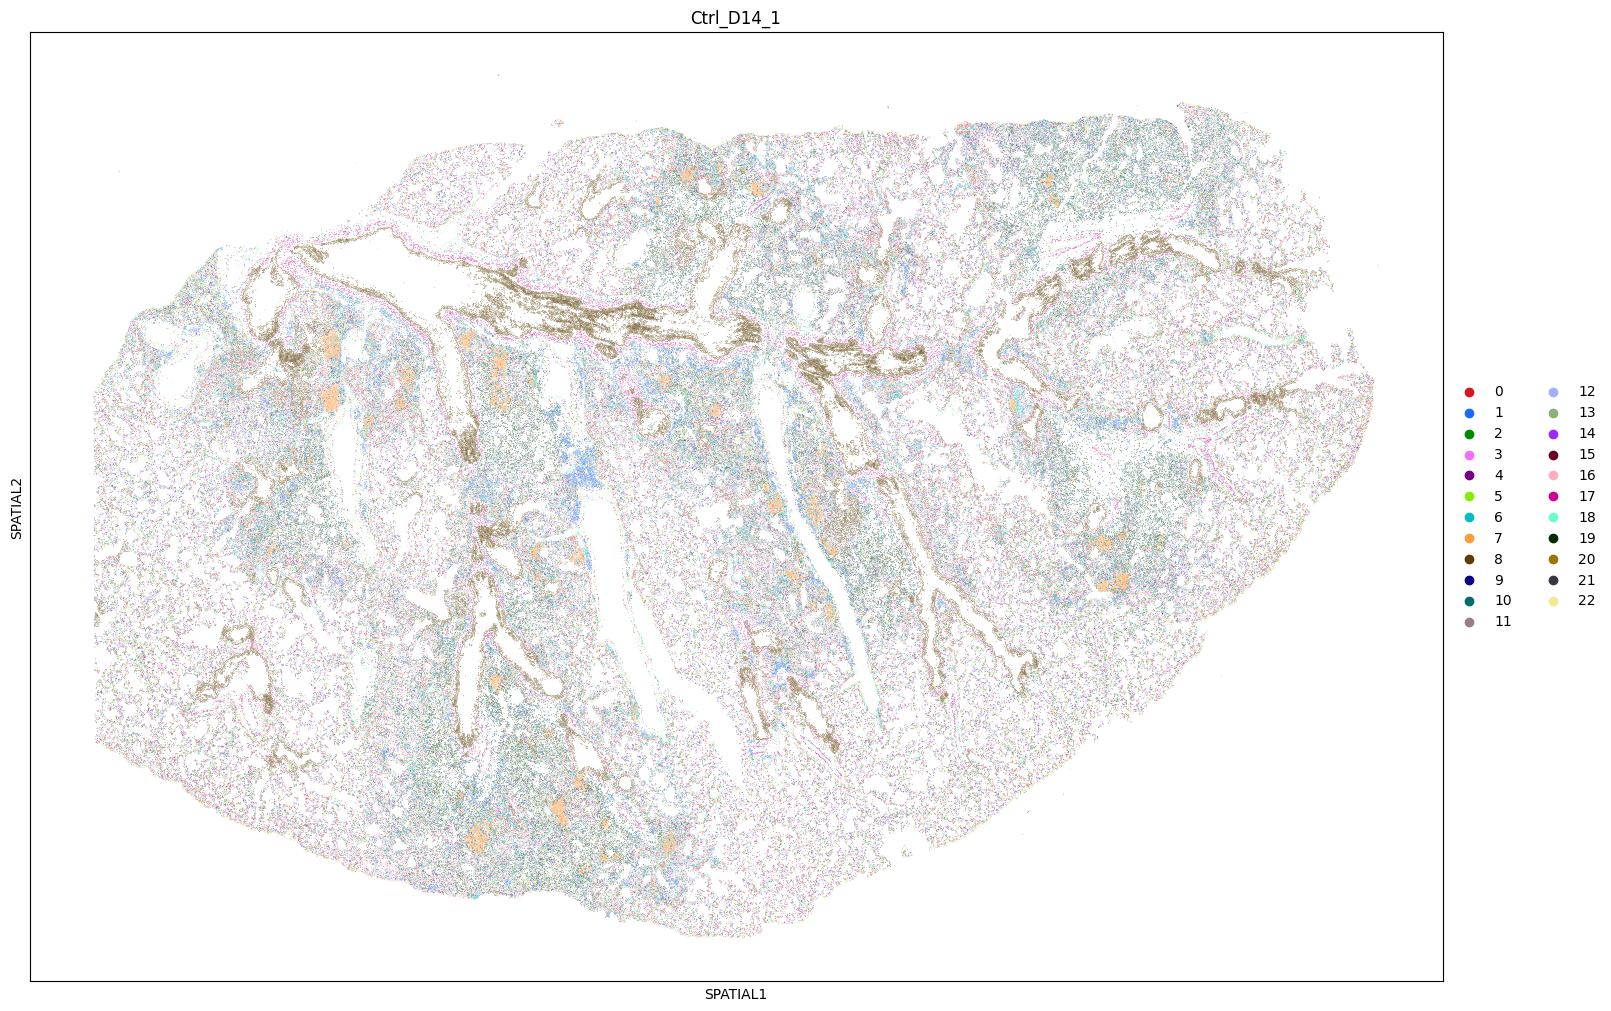

In [100]:
s1 = adata.obs["Sample"].cat.categories[0]
adata_small = adata[adata.obs["Sample"] == s1]
plot_key = "global_leiden_0.8"

f,ax = plt.subplots(1, 1, figsize=(16,10), layout="constrained")
sc.pl.embedding(adata_small, basis='SPATIAL', color=plot_key, palette=color_gen(adata.obs[plot_key].cat.categories), title=s1, ax=ax, show=False, size=1)
f.savefig(PLOTDIR / "LeidenCluster-Spatial_leiden_0.8 SAMPLE.jpg")

# Save/Load

In [94]:
# save
adata.write(DATADIR / "integrated.h5ad")
adata

AnnData object with n_obs × n_vars = 4654531 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'Slide', 'Sample', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'global_leiden_1.3', 'global_leiden_1.4', 'global_leiden_1.5', 'Genotype', 'Timepoint'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCA', 'UMAP', 'globa

In [ ]:
# load
adata = sc.read_h5ad(DATADIR / "integrated.h5ad")
adata

# Sandbox

In [ ]:
# DEG for clusters
RUN_DEG = True
select_res = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# change to string for DEGs
for col in adata.obs.columns:
    if "leiden" in col:
        adata.obs[col] = adata.obs[col].astype(str).astype("category")

for res in select_res:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    de_key = f"{DE_KEY}_{res:.1f}"
    n_clust = len(adata.obs[res_key].unique())

    # calculate DEGs
    if RUN_DEG is True:
        clear_uns(adata, res_key)
        sc.tl.rank_genes_groups(
            adata,
            groupby=res_key,
            key_added=de_key,
            use_raw=False,
            layer="normalized",
            # method="wilcoxon",
        )

    # plot DEGs
    N_genes = 20
    top_genes = {}
    for group, df in sc.get.rank_genes_groups_df(adata, group=None, key=de_key).groupby(
        "group"
    ):
        top_genes[group] = df["names"][:N_genes].tolist()

    f, ax = plt.subplots(1, 1, figsize=(n_clust * 5, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        adata,
        groupby=res_key,
        key=de_key,
        # n_genes=20,
        var_names=top_genes,
        # standard_scale="var",
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key}_DEGs",
        vmin=-4,
        vmax=4,
    )

    sc.pl.rank_genes_groups_heatmap(
        adata,
        key=de_key,
        groupby=res_key,
        layer="normalized",
        n_genes=30,
    )

In [ ]:
for col in ["leiden_0.5", "leiden_0.8"]:
    adata.obs[["cell_id", col]].rename(columns={col: "group"}).to_csv(
        DATADIR / f"0038439_{col}.csv"
    )